In [1]:
import pandas as pd

from matplotlib import pyplot as plt

from pathlib import Path

In [2]:
DATA_DIR = Path(f"../../artifacts/2023-06-s8/trail-long-run/distillation")

In [34]:
def load_data(dataset, layer, n, compr, basis_name, model, seeds=[1, 2, 3, 4, 5]):
    
    data_dir = DATA_DIR / dataset / model
    
    arr_dfs = []
    
    
    
    
    for seed in seeds:
        slug =  f"layer{layer}-n{n}-comp{compr}-seed{seed}/{basis_name}--centered"

        _df = pd.read_csv(data_dir / slug / "result.csv")
        _df["seed"] = seed
    
        arr_dfs.append(_df)
        
    return pd.concat(arr_dfs)

load_data(
    "cifar100-35vs98",
    layer="layer3",
    n=60,
    compr=0.01,
    model="cifar100-resnet18-p1",
    basis_name="random1"
)

,layer,epoch,epoch_auroc,teacher_auroc,student_auroc_before_training,student_trainable_param,student_total_params,teacher_total_params,seed
0,layer3,0,0.5635,0.7933,0.5199,2608,9123028,11220132,1
1,layer3,1,0.5824,0.7933,0.5199,2608,9123028,11220132,1
2,layer3,2,0.6002,0.7933,0.5199,2608,9123028,11220132,1
3,layer3,3,0.6081,0.7933,0.5199,2608,9123028,11220132,1
4,layer3,4,0.6005,0.7933,0.5199,2608,9123028,11220132,1
...,...,...,...,...,...,...,...,...,...
95,layer3,95,0.6102,0.7933,0.5528,2608,9123028,11220132,5
96,layer3,96,0.6100,0.7933,0.5528,2608,9123028,11220132,5
97,layer3,97,0.6087,0.7933,0.5528,2608,9123028,11220132,5
98,layer3,98,0.6018,0.7933,0.5528,2608,9123028,11220132,5


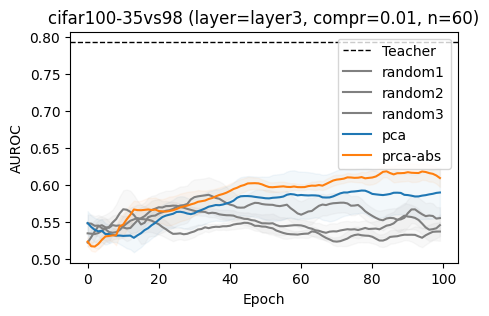

In [35]:
def get_color(name):
    if "random" in name:
        return "gray"
    else:
        return None
    
def viz(dataset, layer, n, compr, seeds=list(range(1, 5+1)), model="cifar100-resnet18-p1"):
    basis_names = [
        "random1", 
        "random2", 
        "random3",
        "pca",
        "prca-abs"
    ]
    
    plt.figure(figsize=(5, 3))
    
    for bix, basis_name in enumerate(basis_names):
        df = load_data(
            dataset=dataset,
            layer=layer,
            n=n,
            compr=compr,
            basis_name=basis_name,
            seeds=seeds,
            model=model
        )
        
        
        epochs = df[df.seed==1].epoch.values
        
        if bix == 0:
            teacher_auroc = df[df.seed==1].teacher_auroc.values[-1]
            plt.axhline(teacher_auroc, ls="--", lw=1, color="k", label="Teacher")
        
        mean = df.groupby(by="epoch")["epoch_auroc"].mean()
        std = df.groupby(by="epoch")["epoch_auroc"].std()
        count = df.groupby(by="epoch")["epoch_auroc"].count()
        
        stderr = std / (count)**0.5

        plt.plot(
            epochs,
            mean,
            label=basis_name,
#             marker=".",
            color=get_color(basis_name)
        )
        
        color = plt.gca().lines[-1].get_color()
        plt.fill_between(
            epochs,
           mean - stderr,
           mean + stderr,
           alpha=0.05,
           color=color
        )
        
    plt.legend()
    plt.ylabel("AUROC")
    plt.xlabel("Epoch")
    plt.title(f"{dataset} (layer={layer}, compr={compr}, n={n})")
        
viz(dataset="cifar100-35vs98", layer="layer3", n=60, compr=0.01)

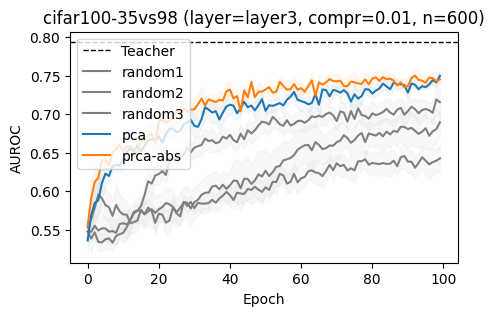

In [28]:
viz(dataset="cifar100-35vs98", layer="layer3", n=600, compr=0.01)

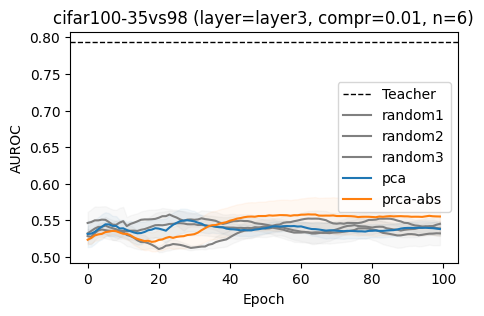

In [29]:
viz(dataset="cifar100-35vs98", layer="layer3", n=6, compr=0.01)

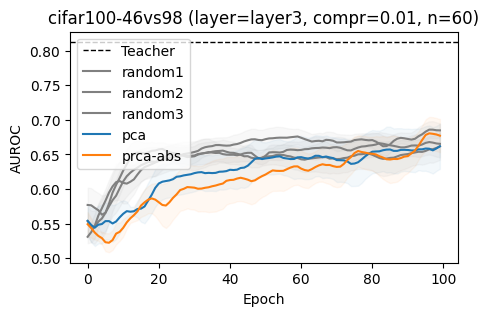

In [30]:
viz(dataset="cifar100-46vs98", layer="layer3", n=60, compr=0.01)

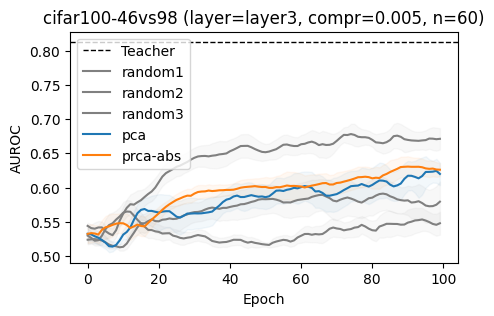

In [31]:
viz(dataset="cifar100-46vs98", layer="layer3", n=60, compr=0.005)

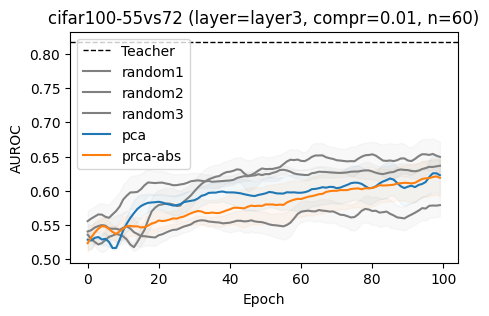

In [12]:
viz(dataset="cifar100-55vs72", layer="layer3", n=60, compr=0.01)

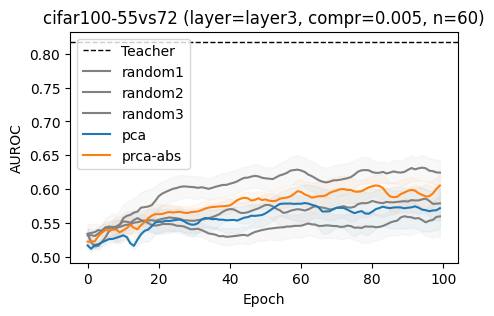

In [16]:
viz(dataset="cifar100-55vs72", layer="layer3", n=60, compr=0.005)

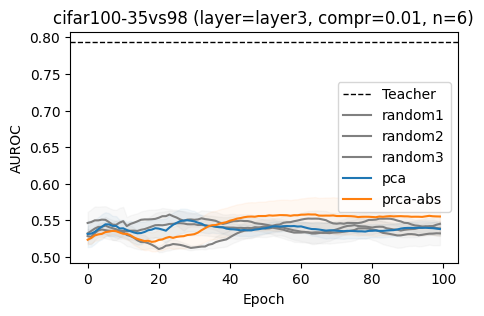

In [7]:
viz(dataset="cifar100-35vs98", layer="layer3", n=6, compr=0.01)

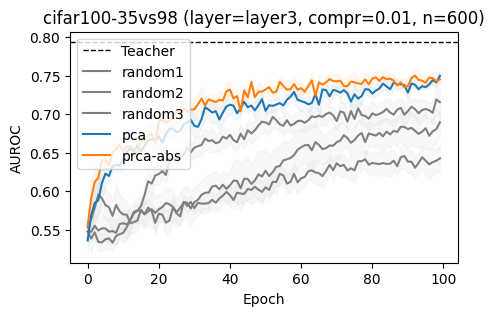

In [8]:
viz(dataset="cifar100-35vs98", layer="layer3", n=600, compr=0.01)

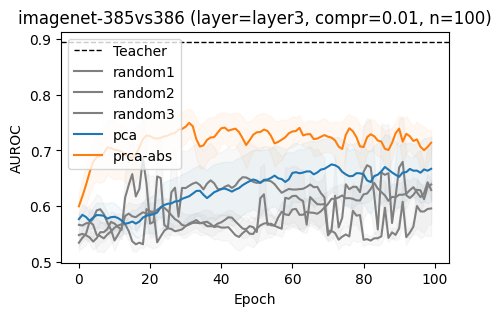

In [55]:
viz(dataset="imagenet-385vs386", layer="layer3", n=100, compr=0.01, model="imagenet-resnet18-tv")

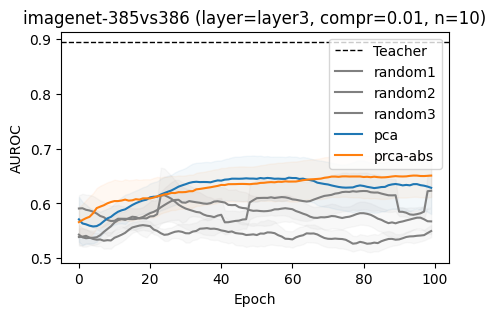

In [57]:
viz(dataset="imagenet-385vs386", layer="layer3", n=10, compr=0.01, model="imagenet-resnet18-tv")

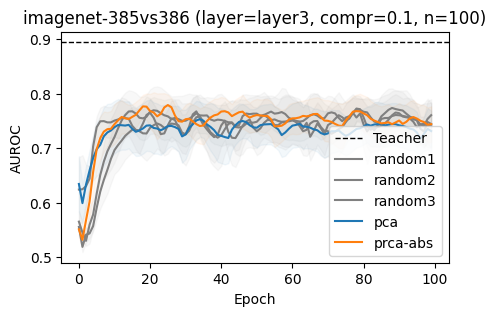

In [54]:
viz(dataset="imagenet-385vs386", layer="layer3", n=100, compr=0.1, model="imagenet-resnet18-tv")

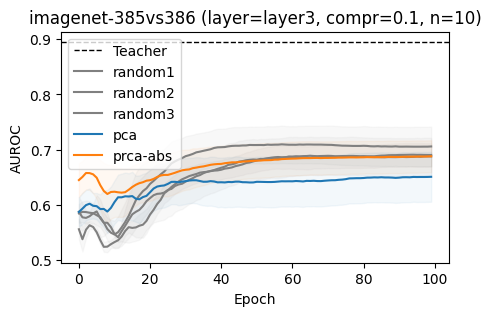

In [59]:
viz(dataset="imagenet-385vs386", layer="layer3", n=10, compr=0.1, model="imagenet-resnet18-tv")

In [44]:
!ls -la  ../../artifacts/2023-06-s8/trail-long-run/distillation/imagenet-385vs386/imagenet-resnet18-tv/layerlayer3-n60-comp0.01-seed3

ls: cannot access '../../artifacts/2023-06-s8/trail-long-run/distillation/imagenet-385vs386/imagenet-resnet18-tv/layerlayer3-n60-comp0.01-seed3': No such file or directory


In [9]:
viz(layer="layer3", n=600, compr=0.01)

TypeError: viz() missing 1 required positional argument: 'dataset'

In [ ]:
viz(layer="layer3", n=60, compr=0.1)

In [ ]:
viz(layer="layer3", n=60, compr=0.01)

In [ ]:
viz(layer="layer3", n=6, compr=0.01)

In [ ]:
viz(layer="layer4", n=60, compr=0.01)

In [ ]:
viz(layer="layer4", n=60, compr=0.005)